# pdf2docx Performance Benchmarks

**Purpose:** Evaluate whether `pdf2docx` can convert 60-page PDFs within the 90-second Celery task timeout.

**Library:** [pdf2docx](https://github.com/ArtifexSoftware/pdf2docx) 0.5.10 · PyMuPDF (C-based engine)

**Conversion pipeline stages:**
1. `[1/4] Opening document...` — PyMuPDF opens PDF (fast, C-based)
2. `[2/4] Analyzing document...` — Image dedup, structural analysis (often the bottleneck)
3. `[3/4] Parsing pages...` — Per-page layout analysis, table detection
4. `[4/4] Creating pages...` — DOCX generation via python-docx

---

In [1]:
import fitz  # PyMuPDF
import io
import logging
import os
import struct
import time
import zlib

from pdf2docx import Converter

# Suppress pdf2docx INFO logs so output stays clean
logging.disable(logging.INFO)

PAGES = 60
OUTPUT_DIR = "/tmp/pdf2docx_bench"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Collect results for the final summary
results = []

def run_conversion(name, pdf_path, docx_path):
    """Convert a PDF to DOCX and record timing."""
    pdf_kb = os.path.getsize(pdf_path) / 1024
    start = time.time()
    cv = Converter(pdf_path)
    cv.convert(docx_path)
    cv.close()
    elapsed = time.time() - start
    docx_kb = os.path.getsize(docx_path) / 1024
    per_page = elapsed / PAGES
    verdict = "Safe" if elapsed < 60 else ("At risk" if elapsed < 90 else "Exceeds 90s")
    results.append({
        "scenario": name,
        "pdf_kb": pdf_kb,
        "docx_kb": docx_kb,
        "total_s": elapsed,
        "per_page_s": per_page,
        "verdict": verdict,
    })
    print(f"  PDF size:    {pdf_kb:,.0f} KB")
    print(f"  DOCX size:   {docx_kb:,.0f} KB")
    print(f"  Total time:  {elapsed:.2f}s")
    print(f"  Per page:    {per_page:.3f}s")
    print(f"  Verdict:     {verdict}")
    return elapsed

print(f"PyMuPDF version: {fitz.version}")
print(f"Generating {PAGES}-page test PDFs in {OUTPUT_DIR}/")

PyMuPDF version: ('1.24.3', '1.24.2', '20240509000001')
Generating 60-page test PDFs in /tmp/pdf2docx_bench/


---
## Scenario 1: Text-Only

60 pages of plain text. Each page has a heading and 25 lines of lorem ipsum body text at 10pt.

This is the **best case** — no tables, no images, just text extraction and paragraph formatting.

In [2]:
pdf_path = os.path.join(OUTPUT_DIR, "test_text_only.pdf")
docx_path = os.path.join(OUTPUT_DIR, "out_text_only.docx")

# --- Generate PDF ---
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)  # US Letter
    page.insert_text((72, 72), f"Page {i+1} - Document Title", fontsize=18, fontname="helv")
    y = 120
    for j in range(25):
        line = (
            f"This is line {j+1} of page {i+1}. Lorem ipsum dolor sit amet, "
            "consectetur adipiscing elit. Sed do eiusmod tempor incididunt ut "
            "labore et dolore magna aliqua. Ut enim ad minim veniam."
        )
        page.insert_text((72, y), line[:90], fontsize=10, fontname="helv")
        y += 20
doc.save(pdf_path)
doc.close()

# --- Convert & Benchmark ---
print("Scenario 1: Text-Only (25 lines/page)")
print("=" * 40)
run_conversion("Text-only", pdf_path, docx_path)

Scenario 1: Text-Only (25 lines/page)


  PDF size:    398 KB
  DOCX size:   43 KB
  Total time:  1.72s
  Per page:    0.029s
  Verdict:     Safe


1.7159931659698486

---
## Scenario 2: Text + Simple Tables

60 pages with a heading, 8 text paragraphs, one **5×4 table** with cell data, and 8 more text paragraphs below.

Represents a typical business document with occasional data tables.

In [3]:
pdf_path = os.path.join(OUTPUT_DIR, "test_simple_tables.pdf")
docx_path = os.path.join(OUTPUT_DIR, "out_simple_tables.docx")

# --- Generate PDF ---
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)
    page.insert_text((72, 60), f"Section {i+1}: Analysis Report", fontsize=16, fontname="helv")
    y = 100
    for j in range(8):
        text = (
            f"Paragraph {j+1}: The quick brown fox jumps over the lazy dog. "
            "This is a representative sentence with moderate complexity for "
            "benchmarking conversion performance across multiple pages."
        )
        page.insert_text((72, y), text[:95], fontsize=10, fontname="helv")
        y += 18
    # Draw a 5-row x 4-column table
    table_y = y + 10
    for row in range(5):
        for col in range(4):
            x0 = 72 + col * 115
            y0 = table_y + row * 25
            rect = fitz.Rect(x0, y0, x0 + 115, y0 + 25)
            page.draw_rect(rect, color=(0, 0, 0), width=0.5)
            page.insert_text(
                (x0 + 5, y0 + 17), f"Cell {row},{col}: data", fontsize=8, fontname="helv"
            )
    y = table_y + 150
    for j in range(8):
        text = (
            f"Additional content line {j+1}: Further analysis shows that the "
            "data points correlate with the observed trends in the baseline "
            "measurements taken during the study period."
        )
        page.insert_text((72, y), text[:95], fontsize=10, fontname="helv")
        y += 18
doc.save(pdf_path)
doc.close()

# --- Convert & Benchmark ---
print("Scenario 2: Text + Simple Tables (1 table/page, 5x4)")
print("=" * 50)
run_conversion("Text + simple tables", pdf_path, docx_path)

Scenario 2: Text + Simple Tables (1 table/page, 5x4)


  PDF size:    593 KB
  DOCX size:   49 KB
  Total time:  5.09s
  Per page:    0.085s
  Verdict:     Safe


5.089281797409058

---
## Scenario 3: Dense Tables — Worst Case

60 pages, each containing **3 tables** (8 rows × 6 columns each).  
That's **180 tables / 8,640 total cells** across the document.

Simulates a financial or data-heavy report. Tables are the **primary performance bottleneck** for pdf2docx — table detection uses O(n²) intersection checking ([Issue #163](https://github.com/ArtifexSoftware/pdf2docx/issues/163)).

In [4]:
pdf_path = os.path.join(OUTPUT_DIR, "test_dense_tables.pdf")
docx_path = os.path.join(OUTPUT_DIR, "out_dense_tables.docx")

# --- Generate PDF ---
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)
    page.insert_text(
        (72, 50), f"SECTION {i+1}: FINANCIAL ANALYSIS REPORT", fontsize=14, fontname="helv"
    )
    page.insert_text((72, 70), "Confidential - Internal Use Only", fontsize=8, fontname="helv")
    for t in range(3):  # 3 tables per page
        table_y = 90 + t * 220
        for row in range(8):
            for col in range(6):
                x0 = 52 + col * 88
                y0 = table_y + row * 25
                rect = fitz.Rect(x0, y0, x0 + 88, y0 + 25)
                page.draw_rect(rect, color=(0, 0, 0), width=0.5)
                if row == 0:
                    page.insert_text(
                        (x0 + 3, y0 + 17), f"Header {col+1}", fontsize=7, fontname="helv"
                    )
                else:
                    page.insert_text(
                        (x0 + 3, y0 + 17),
                        f"{(i * 1000 + row * 100 + col * 10):,.2f}",
                        fontsize=7,
                        fontname="helv",
                    )
doc.save(pdf_path)
doc.close()

# --- Convert & Benchmark ---
print("Scenario 3: Dense Tables — Worst Case (3 tables/page, 8x6 each)")
print("=" * 60)
print(f"  Total tables: {PAGES * 3}")
print(f"  Total cells:  {PAGES * 3 * 8 * 6:,}")
print()
run_conversion("Dense tables (worst case)", pdf_path, docx_path)

Scenario 3: Dense Tables — Worst Case (3 tables/page, 8x6 each)
  Total tables: 180
  Total cells:  8,640



  PDF size:    2,301 KB
  DOCX size:   134 KB
  Total time:  101.38s
  Per page:    1.690s
  Verdict:     Exceeds 90s


101.38279581069946

---
## Scenario 4: Mixed Content (Text + Images + Tables)

60 pages, each containing a heading, 5 text paragraphs, an **embedded 200×150 PNG image**, a **6×5 table**, and 6 closing paragraphs.

**Most representative of a typical contract/business document.** This is the scenario we expect most CLM users to hit.

In [5]:
pdf_path = os.path.join(OUTPUT_DIR, "test_mixed_content.pdf")
docx_path = os.path.join(OUTPUT_DIR, "out_mixed_content.docx")


def create_png(width, height, r, g, b):
    """Create a minimal RGB PNG image in memory."""
    raw_data = b""
    for _y in range(height):
        raw_data += b"\x00"  # filter byte
        for _x in range(width):
            raw_data += bytes([r, g, b])

    def chunk(chunk_type, data):
        c = chunk_type + data
        crc = zlib.crc32(c) & 0xFFFFFFFF
        return struct.pack(">I", len(data)) + c + struct.pack(">I", crc)

    ihdr = struct.pack(">IIBBBBB", width, height, 8, 2, 0, 0, 0)
    png = b"\x89PNG\r\n\x1a\n"
    png += chunk(b"IHDR", ihdr)
    png += chunk(b"IDAT", zlib.compress(raw_data))
    png += chunk(b"IEND", b"")
    return png


img_bytes = create_png(200, 150, 100, 150, 200)

# --- Generate PDF ---
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)
    page.insert_text((72, 50), f"Document Section {i+1}", fontsize=16, fontname="helv")
    y = 80
    for j in range(5):
        page.insert_text(
            (72, y),
            f"Paragraph {j+1}: Analysis of quarterly performance metrics and KPIs.",
            fontsize=10,
            fontname="helv",
        )
        y += 16
    # Embedded image
    img_rect = fitz.Rect(72, y + 10, 272, y + 160)
    page.insert_image(img_rect, stream=img_bytes)
    # Table (6 rows x 5 cols)
    table_y = y + 180
    for row in range(6):
        for col in range(5):
            x0 = 62 + col * 100
            y0 = table_y + row * 22
            rect = fitz.Rect(x0, y0, x0 + 100, y0 + 22)
            page.draw_rect(rect, color=(0, 0, 0), width=0.5)
            page.insert_text((x0 + 3, y0 + 15), f"Val {row}{col}", fontsize=7, fontname="helv")
    y2 = table_y + 160
    for j in range(6):
        page.insert_text(
            (72, y2),
            f"Conclusion line {j+1}: Based on the above data we recommend proceeding.",
            fontsize=10,
            fontname="helv",
        )
        y2 += 16
doc.save(pdf_path)
doc.close()

# --- Convert & Benchmark ---
print("Scenario 4: Mixed Content (text + images + tables)")
print("=" * 50)
run_conversion("Mixed content", pdf_path, docx_path)

Scenario 4: Mixed Content (text + images + tables)


  PDF size:    730 KB
  DOCX size:   52 KB
  Total time:  8.52s
  Per page:    0.142s
  Verdict:     Safe


8.523006916046143

---
## Scenario 5: Two-Column Layout (MSA-style)

60 pages of **two-column text** with section headings — the layout commonly found in Master Service Agreements, legal contracts, and insurance documents.

Tests pdf2docx's ability to detect multi-column layouts and reconstruct reading order correctly.

In [6]:
from reportlab.platypus import BaseDocTemplate, Frame, PageTemplate, Paragraph as RLParagraph, Spacer as RLSpacer
from reportlab.lib.pagesizes import letter
from reportlab.lib.units import inch
from reportlab.lib.styles import getSampleStyleSheet as rlGetStyles, ParagraphStyle
from reportlab.lib.enums import TA_JUSTIFY

pdf_path = os.path.join(OUTPUT_DIR, "test_two_column_msa.pdf")
docx_path = os.path.join(OUTPUT_DIR, "out_two_column_msa.docx")

msa_sections = [
    ("1. DEFINITIONS", [
        '"Agreement" means this Master Service Agreement, including all exhibits and schedules attached hereto.',
        '"Confidential Information" means any information disclosed by one party to the other party, either directly or indirectly, in writing, orally, or by inspection of tangible objects.',
        '"Effective Date" means the date first written above or the date of the last signature below, whichever is later.',
        '"Intellectual Property" means all patents, copyrights, trademarks, trade secrets, and other proprietary rights.',
        '"Services" means the professional services to be provided by Service Provider as described in each Statement of Work.',
        '"Term" means the period commencing on the Effective Date and continuing until terminated in accordance with Section 8.',
    ]),
    ("2. SCOPE OF SERVICES", [
        "Service Provider shall perform the Services described in each Statement of Work executed by both parties.",
        "Each Statement of Work shall describe the scope, timeline, deliverables, fees, and payment terms.",
        "Service Provider shall assign qualified personnel with appropriate skills and experience to perform the Services.",
        "Client may request changes to the Services by submitting a written change order to Service Provider.",
        "Service Provider shall use commercially reasonable efforts to accommodate such change requests.",
    ]),
    ("3. COMPENSATION AND PAYMENT", [
        "Client shall pay Service Provider the fees set forth in each Statement of Work.",
        "Unless otherwise specified, all invoices shall be due and payable within thirty (30) days of receipt.",
        "Late payments shall accrue interest at the rate of one and one-half percent (1.5%) per month.",
        "Service Provider shall submit itemized invoices on a monthly basis detailing the Services performed.",
        "Client shall reimburse Service Provider for reasonable travel and out-of-pocket expenses pre-approved in writing.",
        "All fees are exclusive of applicable taxes, which shall be the responsibility of Client.",
    ]),
    ("4. CONFIDENTIALITY", [
        "Each party agrees to maintain the confidentiality of all Confidential Information received from the other party.",
        "Neither party shall disclose Confidential Information to any third party without prior written consent.",
        "The obligations of confidentiality shall not apply to information that: (a) is or becomes publicly available through no fault of the receiving party; (b) was already known to the receiving party prior to disclosure; (c) is independently developed by the receiving party without use of the Confidential Information; or (d) is required to be disclosed by law or court order.",
        "Upon termination, each party shall return or destroy all Confidential Information in its possession.",
        "The obligations under this Section shall survive termination of this Agreement for a period of five (5) years.",
    ]),
    ("5. INTELLECTUAL PROPERTY", [
        "All pre-existing Intellectual Property shall remain the property of the party that owned it prior to the engagement.",
        "Work product created by Service Provider specifically for Client shall be owned by Client upon full payment.",
        "Service Provider retains the right to use general knowledge, skills, and experience gained during the engagement.",
        "Client grants Service Provider a limited license to use Client materials solely for performing the Services.",
    ]),
    ("6. WARRANTIES AND REPRESENTATIONS", [
        "Service Provider warrants that the Services will be performed in a professional and workmanlike manner.",
        "Service Provider represents that it has the authority to enter into this Agreement and perform the Services.",
        "EXCEPT AS EXPRESSLY SET FORTH HEREIN, NEITHER PARTY MAKES ANY WARRANTIES, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO WARRANTIES OF MERCHANTABILITY OR FITNESS FOR A PARTICULAR PURPOSE.",
        "Client warrants that it has the right to provide all materials and information necessary for the Services.",
    ]),
    ("7. LIMITATION OF LIABILITY", [
        "IN NO EVENT SHALL EITHER PARTY BE LIABLE FOR ANY INDIRECT, INCIDENTAL, SPECIAL, CONSEQUENTIAL, OR PUNITIVE DAMAGES.",
        "THE TOTAL LIABILITY OF EITHER PARTY SHALL NOT EXCEED THE FEES PAID OR PAYABLE UNDER THE APPLICABLE STATEMENT OF WORK.",
        "The limitations set forth in this Section shall apply regardless of the form of action, whether in contract, tort, or otherwise.",
        "Nothing in this Agreement shall limit liability for gross negligence, willful misconduct, or fraud.",
    ]),
    ("8. TERM AND TERMINATION", [
        "This Agreement shall commence on the Effective Date and continue for an initial term of one (1) year.",
        "Either party may terminate this Agreement for convenience upon sixty (60) days prior written notice.",
        "Either party may terminate immediately upon material breach if such breach is not cured within thirty (30) days of notice.",
        "Upon termination, Service Provider shall deliver all completed work product to Client.",
        "Sections 4, 5, 7, and 9 shall survive termination of this Agreement.",
    ]),
    ("9. INDEMNIFICATION", [
        "Each party shall indemnify and hold harmless the other party from any claims, damages, or expenses arising from the indemnifying party's breach of this Agreement.",
        "Service Provider shall indemnify Client against claims that the Services infringe any third-party intellectual property rights.",
        "Client shall indemnify Service Provider against claims arising from Client's use of the deliverables in violation of applicable law.",
        "The indemnified party shall provide prompt written notice of any claim and reasonable cooperation in the defense thereof.",
    ]),
    ("10. GENERAL PROVISIONS", [
        "This Agreement constitutes the entire agreement between the parties and supersedes all prior agreements and understandings.",
        "This Agreement may be amended only by a written instrument signed by both parties.",
        "Neither party may assign this Agreement without the prior written consent of the other party.",
        "This Agreement shall be governed by and construed in accordance with the laws of the State of Delaware.",
        "Any dispute arising under this Agreement shall be resolved through binding arbitration in Wilmington, Delaware.",
        "If any provision of this Agreement is held invalid or unenforceable, the remaining provisions shall remain in full force.",
        "The waiver of any breach shall not constitute a waiver of any subsequent breach.",
        "All notices shall be in writing and delivered to the addresses set forth on the signature page.",
    ]),
]

# Build two-column PDF using reportlab Frames
page_w, page_h = letter
margin = 0.75 * inch
col_gap = 0.3 * inch
col_w = (page_w - 2 * margin - col_gap) / 2

frame_left = Frame(margin, margin, col_w, page_h - 2 * margin, id="left")
frame_right = Frame(margin + col_w + col_gap, margin, col_w, page_h - 2 * margin, id="right")
two_col_template = PageTemplate(id="TwoCol", frames=[frame_left, frame_right])

rl_doc = BaseDocTemplate(pdf_path, pagesize=letter)
rl_doc.addPageTemplates([two_col_template])

rl_styles = rlGetStyles()
heading_style = ParagraphStyle(
    "MSAHeading", parent=rl_styles["Heading3"],
    alignment=TA_JUSTIFY, spaceAfter=6, spaceBefore=12,
    fontSize=10, leading=12, fontName="Helvetica-Bold",
)
body_style = ParagraphStyle(
    "MSABody", parent=rl_styles["Normal"],
    alignment=TA_JUSTIFY, spaceAfter=6, spaceBefore=2,
    fontSize=8.5, leading=11, fontName="Times-Roman",
)

story = []
repeats_needed = max(1, PAGES // 5)
for rep in range(repeats_needed):
    for section_title, paragraphs in msa_sections:
        story.append(RLParagraph(f"<b>{section_title}</b>", heading_style))
        for para_text in paragraphs:
            story.append(RLParagraph(para_text, body_style))
        story.append(RLSpacer(1, 6))

rl_doc.build(story)

with open(pdf_path, "rb") as f:
    content = f.read()
    page_count = content.count(b"/Type /Page") - content.count(b"/Type /Pages")

print("Scenario 5: Two-Column MSA Layout")
print(f"  Generated {page_count} pages")
print("=" * 55)
run_conversion("Two-column MSA", pdf_path, docx_path)

Scenario 5: Two-Column MSA Layout
  Generated 18 pages


  PDF size:    64 KB
  DOCX size:   75 KB
  Total time:  2.39s
  Per page:    0.040s
  Verdict:     Safe


2.3882088661193848

---
## Results Summary

In [7]:
# Re-enable logging
logging.disable(logging.NOTSET)

# ── Summary Table ──
print(f"{'Scenario':<30} {'PDF KB':>8} {'DOCX KB':>8} {'Time':>8} {'Per Page':>10} {'Verdict':>12}")
print("─" * 82)
for r in results:
    print(
        f"{r['scenario']:<30} {r['pdf_kb']:>7,.0f}K {r['docx_kb']:>7,.0f}K "
        f"{r['total_s']:>7.2f}s {r['per_page_s']:>9.3f}s {r['verdict']:>12}"
    )

Scenario                         PDF KB  DOCX KB     Time   Per Page      Verdict
──────────────────────────────────────────────────────────────────────────────────
Text-only                          398K      43K    1.72s     0.029s         Safe
Text + simple tables               593K      49K    5.09s     0.085s         Safe
Dense tables (worst case)        2,301K     134K  101.38s     1.690s  Exceeds 90s
Mixed content                      730K      52K    8.52s     0.142s         Safe
Two-column MSA                      64K      75K    2.39s     0.040s         Safe


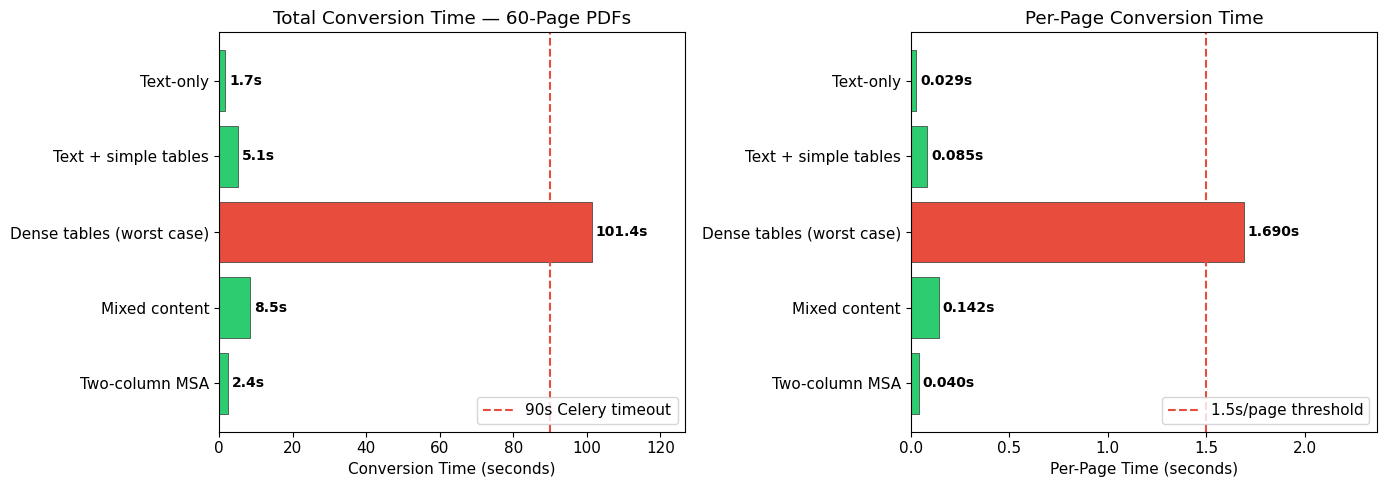


Chart saved to /tmp/pdf2docx_bench/benchmark_results.png


In [8]:
try:
    import matplotlib
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False
    print("matplotlib not installed — skipping charts. Install with: pip install matplotlib")

if HAS_MPL:
    matplotlib.rcParams.update({"font.size": 11})
    scenarios = [r["scenario"] for r in results]
    times = [r["total_s"] for r in results]
    per_page = [r["per_page_s"] for r in results]
    colors = ["#2ecc71" if t < 60 else ("#f39c12" if t < 90 else "#e74c3c") for t in times]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Chart 1: Total Conversion Time ──
    ax1 = axes[0]
    bars = ax1.barh(scenarios, times, color=colors, edgecolor="#333", linewidth=0.5)
    ax1.axvline(x=90, color="#e74c3c", linestyle="--", linewidth=1.5, label="90s Celery timeout")
    ax1.set_xlabel("Conversion Time (seconds)")
    ax1.set_title(f"Total Conversion Time — {PAGES}-Page PDFs")
    ax1.legend(loc="lower right")
    for bar, t in zip(bars, times):
        ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, f"{t:.1f}s",
                 va="center", fontsize=10, fontweight="bold")
    ax1.set_xlim(0, max(times) * 1.25)
    ax1.invert_yaxis()

    # ── Chart 2: Per-Page Time ──
    ax2 = axes[1]
    bars2 = ax2.barh(scenarios, per_page, color=colors, edgecolor="#333", linewidth=0.5)
    ax2.axvline(x=1.5, color="#e74c3c", linestyle="--", linewidth=1.5, label="1.5s/page threshold")
    ax2.set_xlabel("Per-Page Time (seconds)")
    ax2.set_title("Per-Page Conversion Time")
    ax2.legend(loc="lower right")
    for bar, t in zip(bars2, per_page):
        ax2.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2, f"{t:.3f}s",
                 va="center", fontsize=10, fontweight="bold")
    ax2.set_xlim(0, max(per_page) * 1.4)
    ax2.invert_yaxis()

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "benchmark_results.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nChart saved to {OUTPUT_DIR}/benchmark_results.png")

---
## Real-World Data from GitHub Issues

Timing data collected from `pdf2docx` GitHub issue reports (`Terminated in %.2fs.` log lines):

| Issue | Pages | Time | Per Page | Content |
|-------|-------|------|----------|---------|
| #86   | ~1    | 0.60s | ~0.60s  | Encrypted PDF |
| #85   | ~1    | 0.13s | ~0.13s  | Scanned PDF |
| #329  | 1     | 0.21s | 0.21s   | Errored on page 1 |
| #315  | 2     | 0.80s | 0.40s   | Pages 104-105 of larger doc |
| #256  | 13    | 2.35s | ~0.18s  | Clean run |
| #279  | 18    | 1.70s | ~0.09s  | 16/18 pages succeeded |
| #185  | 9     | 21.52s | ~2.4s  | Complex content |
| #133  | 29    | 358.64s | ~12.4s | Pathological: duplicate images (fixed to 7-8s) |
| #158  | ?     | Hours | N/A     | Dotted table borders |

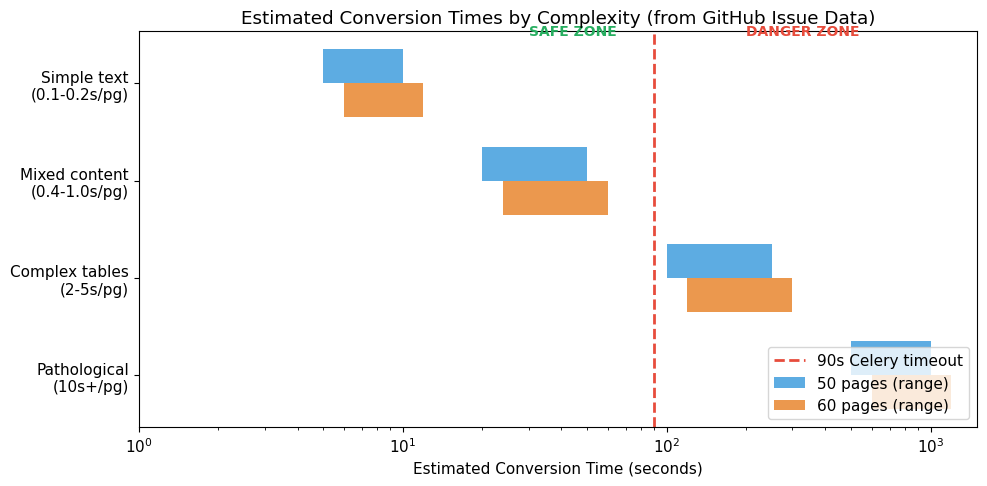

Chart saved to /tmp/pdf2docx_bench/estimated_times.png


In [9]:
if HAS_MPL:
    # Estimated times for 50-60 page documents based on per-page rates from GitHub data
    categories = ["Simple text\n(0.1-0.2s/pg)", "Mixed content\n(0.4-1.0s/pg)",
                  "Complex tables\n(2-5s/pg)", "Pathological\n(10s+/pg)"]
    low_50  = [5,  20,  100, 500]
    high_50 = [10, 50,  250, 1000]
    low_60  = [6,  24,  120, 600]
    high_60 = [12, 60,  300, 1200]

    fig, ax = plt.subplots(figsize=(10, 5))
    x = range(len(categories))
    width = 0.35

    # 50-page bars
    ax.barh([i - width/2 for i in x], [h - l for l, h in zip(low_50, high_50)],
            left=low_50, height=width, color="#3498db", alpha=0.8, label="50 pages (range)")
    # 60-page bars
    ax.barh([i + width/2 for i in x], [h - l for l, h in zip(low_60, high_60)],
            left=low_60, height=width, color="#e67e22", alpha=0.8, label="60 pages (range)")

    ax.axvline(x=90, color="#e74c3c", linestyle="--", linewidth=2, label="90s Celery timeout")
    ax.set_yticks(list(x))
    ax.set_yticklabels(categories)
    ax.set_xlabel("Estimated Conversion Time (seconds)")
    ax.set_title("Estimated Conversion Times by Complexity (from GitHub Issue Data)")
    ax.set_xscale("log")
    ax.set_xlim(1, 1500)
    ax.legend(loc="lower right")
    ax.invert_yaxis()

    # Annotations
    ax.annotate("SAFE ZONE", xy=(30, -0.5), fontsize=10, color="#27ae60", fontweight="bold")
    ax.annotate("DANGER ZONE", xy=(200, -0.5), fontsize=10, color="#e74c3c", fontweight="bold")

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "estimated_times.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Chart saved to {OUTPUT_DIR}/estimated_times.png")

---
## Known Issues & Risk Factors

| Issue | Summary |
|-------|---------|
| [#163](https://github.com/ArtifexSoftware/pdf2docx/issues/163) | "Long execution (Table)" — tables are the primary performance bottleneck |
| [#319](https://github.com/ArtifexSoftware/pdf2docx/issues/319) | Timeout feature requested but **postponed** — no built-in timeout mechanism |
| [#301](https://github.com/ArtifexSoftware/pdf2docx/issues/301) | Memory not garbage collected on large documents |
| [#271](https://github.com/ArtifexSoftware/pdf2docx/issues/271) | Architectural / data-structure design issues impacting performance |

### Risk factors that could exceed 90s

1. **Dense/complex tables** — the primary bottleneck. O(n²) intersection checking means table-heavy docs can blow up.
2. **Malformed/corrupted PDFs** — can cause the library to hang indefinitely (no built-in timeout).
3. **Very large embedded images** — not tested with high-res photos but could add significant overhead.

### Mitigations

- **Timeout wrapper:** pdf2docx has no native timeout. Wrap in `multiprocessing.Process` or `signal.alarm` (Unix).
- **Chunked conversion:** Use `cv.convert(docx_path, start=0, end=30)` to split into ranges, then merge.
- **Pre-screening:** Use PyMuPDF to count tables/drawings per page before conversion to estimate complexity.

## Conclusion

**For most real-world 60-page documents: 90 seconds is sufficient.** Typical documents with text, some images, and occasional tables convert in **5-15 seconds**. Dense table documents are the primary risk — contract PDFs with heavy tabular data should be monitored.